In [1]:
import numpy as np
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')
import h5py
from cartopy.crs import EqualEarth, PlateCarree    # 0.22.0

#### 1) Open $C^*$ values (in mmol/m$^3$) for all years (1992-2022) and store them as a stacked array.

For each year, $C^*(x,y,z)$ is on a regular (lat, lon, depth) grid with $(180, 360, 50)$ grid points.

In [3]:
data_folder = "../raw_Cstar_data/"
years = list(range(1992, 2023))  #31 years: 1992 to 2022
cstar_stack = []

#Load each year's file and append to list
for y in years:
    path = os.path.join(data_folder, f"cstar_interp_{y}.h5")
    with h5py.File(path, 'r') as f:
        cstar = f['Cstar'][:] # Use [:] to load data into memory
    cstar_stack.append(cstar)

# load latitude and depth arrays
with h5py.File(path, 'r') as f:
    lat = f['latitude'][:] 
    lon = f['longitude'][:] 

#Stack
cstar_all = np.stack(cstar_stack, axis=-1)         
print('Shape of stacked array (lat, lon, depth, years): ', cstar_all.shape)

Shape of stacked array (lat, lon, depth, years):  (180, 360, 50, 31)


In [4]:
# Load \Delta z (vertical grid spacing)
drf_path = "../processed_data/DRF.data" 
drf = np.fromfile(drf_path, dtype='>f4')[:50]

#### 2) Compute vertically-integrated $\Delta C^*$

For each grid point $(x,y,z)$, the annual timeseries $C^*(x,y,z,t)$ is extracted over a specified time period (a particular decade or the full time period of analysis). $\Delta C^*$ is computed using linear regression over that specified time period.

In [6]:
#Compute rate of change of C^* over a specific period
def compute_decadal_slope(data, years, start, end, drf):
    # Select timeseries indices for the selected time period
    idx = [i for i, y in enumerate(years) if start <= y <= end]
    x = np.array(years)[idx]
    dC = np.full((180, 360, 50), np.nan)
    dC_int = np.full((180, 360), np.nan)

    for i in range(180):
        for j in range(360):
            for k in range(50):

                y = data[i, j, k, idx]  #shape: (years)
                if np.isnan(y).all():
                    continue  # skip all NaN (land)
                if linregress(x, y).pvalue < 0.05:
                    dC[i, j, k] = linregress(x, y).slope # rate of change of C^* at a given grid point
                
            temp = dC[i, j, :] #extract as 1d 
            if np.isnan(temp).all():
                continue  #skip all NaN
            col_sum = np.nansum(temp * drf) # integrate vertically
            dC_int[i, j] = col_sum/1000 # units: mmol/m^2/yr --> mol/m^2/yr

    return dC_int

In [7]:
# Compute rate of change for 1992-2022
slope_1993_2022 = compute_decadal_slope(cstar_all, years, 1993, 2022, drf) #mol/m^2/yr

# Compute rate of change for 1993-2002
slope_1993_2002 = compute_decadal_slope(cstar_all, years, 1993, 2002, drf) #mol/m^2/yr

# Compute rate of change for 2003-2012
slope_2003_2012 = compute_decadal_slope(cstar_all, years, 2003, 2012, drf) #mol/m^2/yr

# Compute rate of change for 2013-2022
slope_2013_2022 = compute_decadal_slope(cstar_all, years, 2013, 2022, drf) #mol/m^2/yr

Save data as HDF5 file

In [9]:
with h5py.File('../processed_data/vertical_dCstar.h5', 'w') as f:
    dset = f.create_dataset('dCstar_1993_2002', data=slope_1993_2002)
    f.create_dataset('dCstar_2003_2012', data=slope_2003_2012)
    f.create_dataset('dCstar_2013_2022', data=slope_2013_2022)
    f.create_dataset('dCstar_1993_2022', data=slope_1993_2022)
    f['dCstar_1993_2002'].attrs['unit'] = 'mol/m^2/yr'
    f['dCstar_2003_2012'].attrs['unit'] = 'mol/m^2/yr'
    f['dCstar_2013_2022'].attrs['unit'] = 'mol/m^2/yr'
    f['dCstar_1993_2022'].attrs['unit'] = 'mol/m^2/yr'
    f.create_dataset('latitude', data=lat)
    f.create_dataset('longitude', data=lon)

#### 3) Reproduce manuscript figures

- Vertically-integrated $\Delta C^*$ for 1993-2002, 2003-2012, 2013-2022, and 1993-2022 time periods

- Decadal differences of vertically-integrated $\Delta C^*$ (1993-2012 and 2003-2022)

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

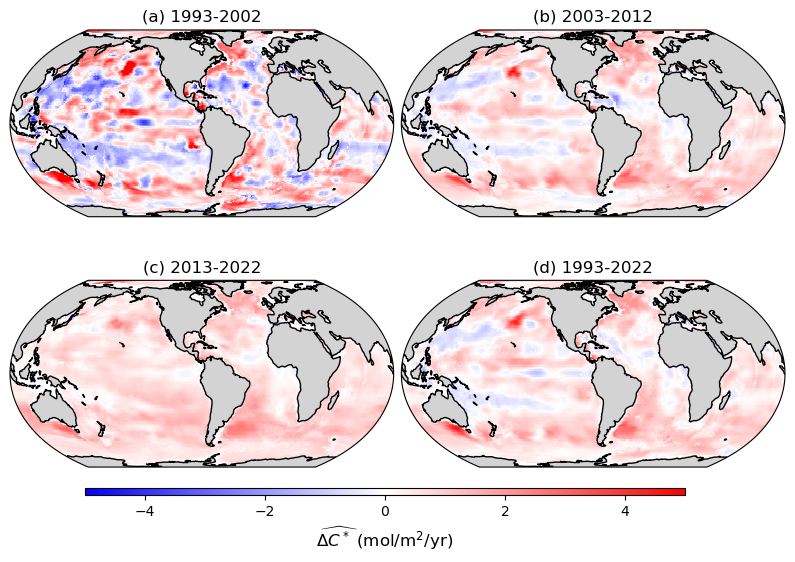

In [12]:
fig = plt.figure(figsize=(10, 7))
cmap = mpl.colormaps.get_cmap('bwr')  
cmap.set_bad(color='dimgrey', alpha=0.0) 
vmax = 5
proj = EqualEarth(central_longitude=-80)
ax = fig.add_subplot(2, 2, 4, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, slope_1993_2022, 
         cmap=cmap, vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title='(d) 1993-2022')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)
#plt.colorbar(im, ax=ax)

ax = fig.add_subplot(2, 2, 1, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, slope_1993_2002, 
         cmap=cmap, vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title='(a) 1993-2002')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)
#plt.colorbar(im, ax=ax)

ax = fig.add_subplot(2, 2, 2, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, slope_2003_2012, 
         cmap=cmap, vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title='(b) 2003-2012')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)

ax = fig.add_subplot(2, 2, 3, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, slope_2013_2022, 
         cmap=cmap, vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title='(c) 2013-2022')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)

fig.subplots_adjust(bottom=0.125, wspace=0.02, hspace=-0.1)
cbar_ax = fig.add_axes([0.2, 0.15, 0.6, 0.01])
cb = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", pad=0.2)
cb.set_label(r'$\widehat{\Delta C^*}$ (mol/m$^2$/yr)', fontsize=12)

plt.show()
fig.savefig("../figures/vert_int_deltaCstar.png", dpi=600, bbox_inches='tight')

In [13]:
# Compute decadal differences:
ddCstar_1993_2012 = slope_2003_2012 - slope_1993_2002
ddCstar_2003_2022 = slope_2013_2022 - slope_2003_2012

Extract data points that fall within each of the four categories:

1. $\Delta \widehat{\Delta C^*}>0$ and $\widehat{\Delta C^*}>0$ for the first decadal period indicating an acceleration in the increasing rates of ocean carbon storage;
2.  $\Delta \widehat{\Delta C^*}<0$ and $\widehat{\Delta C^*}>0$ for the first decadal period indicating a deceleration in the increasing rates or possibly a shift to decreasing rates of ocean carbon storage;
3.  $\Delta \widehat{\Delta C^*}>0$ and $\widehat{\Delta C^*}<0$ for the first decadal period indicating a deceleration in the decreasing rates or possibly a shift to increasing of ocean carbon storage;
4.  $\Delta \widehat{\Delta C^*}<0$ and $\widehat{\Delta C^*}<0$ for the first decadal period indicating an acceleration in the decreasing rates of ocean carbon storage.


In [15]:
# Decadal comparison: 2003-2012 and 1993-2002

# Category 1
ddCstar_1993_2012_pp = ddCstar_1993_2012.copy()
ddCstar_1993_2012_pp[(ddCstar_1993_2012<0) | (slope_1993_2002<0)] = np.nan

# Category 2
ddCstar_1993_2012_nn = ddCstar_1993_2012.copy()
ddCstar_1993_2012_nn[(ddCstar_1993_2012>0) | (slope_1993_2002>0)] = np.nan

# Category 3
ddCstar_1993_2012_pn = ddCstar_1993_2012.copy()
ddCstar_1993_2012_pn[(ddCstar_1993_2012<0) | (slope_1993_2002>0)] = np.nan

# Category 4
ddCstar_1993_2012_np = ddCstar_1993_2012.copy()
ddCstar_1993_2012_np[(ddCstar_1993_2012>0) | (slope_1993_2002<0)] = np.nan

In [16]:
# Decadal comparison: 2013-2022 and 2003-2012

# Category 1
ddCstar_2003_2022_pp = ddCstar_2003_2022.copy()
ddCstar_2003_2022_pp[(ddCstar_2003_2022<0) | (slope_2003_2012<0)] = np.nan

# Category 2
ddCstar_2003_2022_nn = ddCstar_2003_2022.copy()
ddCstar_2003_2022_nn[(ddCstar_2003_2022>0) | (slope_2003_2012>0)] = np.nan

# Category 3
ddCstar_2003_2022_pn = ddCstar_2003_2022.copy()
ddCstar_2003_2022_pn[(ddCstar_2003_2022<0) | (slope_2003_2012>0)] = np.nan

# Category 4
ddCstar_2003_2022_np = ddCstar_2003_2022.copy()
ddCstar_2003_2022_np[(ddCstar_2003_2022>0) | (slope_2003_2012<0)] = np.nan

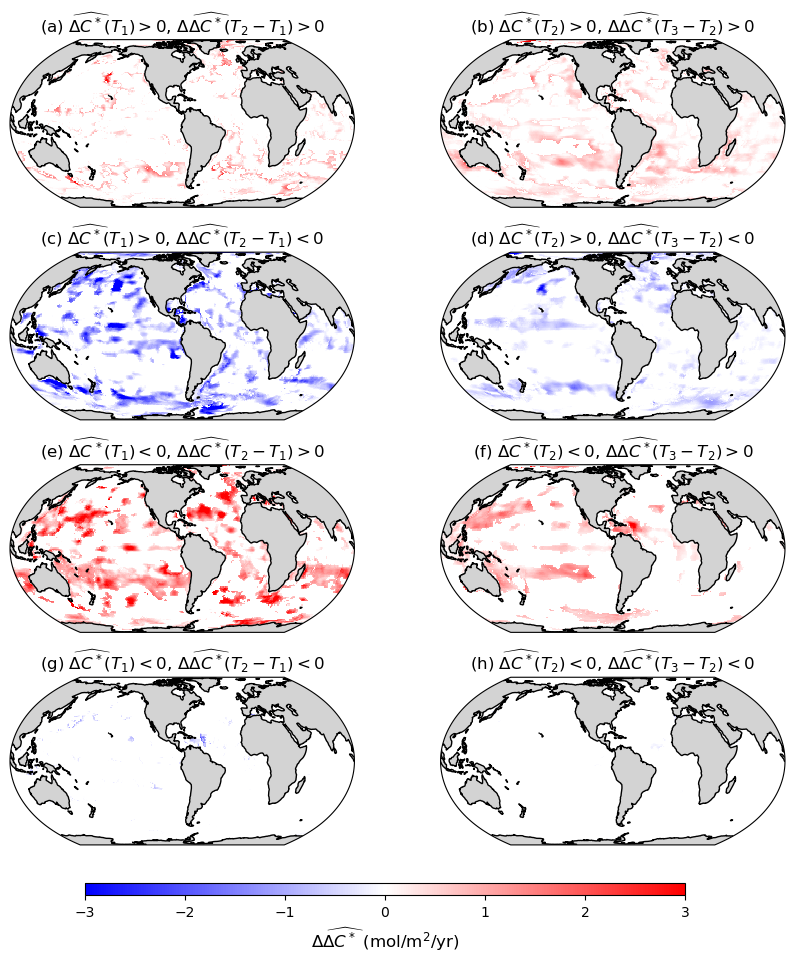

In [17]:
fig = plt.figure(figsize=(10, 12))
vmax = 3
proj = EqualEarth(central_longitude=-80)
ax = fig.add_subplot(4, 2, 1, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, ddCstar_1993_2012_pp, 
         cmap='bwr', vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title=r'(a) $\widehat{\Delta C^*}(T_1)>0, \, \Delta\widehat{\Delta C^*}(T_2-T_1)>0 $')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)

ax = fig.add_subplot(4, 2, 3, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, ddCstar_1993_2012_np, 
         cmap='bwr', vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title=r'(c) $\widehat{\Delta C^*}(T_1)>0, \, \Delta\widehat{\Delta C^*}(T_2-T_1)<0$')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)

ax = fig.add_subplot(4, 2,5, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, ddCstar_1993_2012_pn, 
         cmap='bwr', vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title=r'(e) $\widehat{\Delta C^*}(T_1)<0, \, \Delta\widehat{\Delta C^*}(T_2-T_1)>0$')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)


ax = fig.add_subplot(4, 2, 7, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, ddCstar_1993_2012_nn, 
         cmap='bwr', vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title=r'(g) $\widehat{\Delta C^*}(T_1)<0, \, \Delta\widehat{\Delta C^*}(T_2-T_1)<0$')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)


ax = fig.add_subplot(4, 2, 2, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, ddCstar_2003_2022_pp, 
         cmap='bwr', vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title=r'(b) $\widehat{\Delta C^*}(T_2)>0, \, \Delta\widehat{\Delta C^*}(T_3-T_2)>0$')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)

ax = fig.add_subplot(4, 2, 4, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, ddCstar_2003_2022_np, 
         cmap='bwr', vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title=r'(d) $\widehat{\Delta C^*}(T_2)>0, \, \Delta\widehat{\Delta C^*}(T_3-T_2)<0$')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)

ax = fig.add_subplot(4, 2, 6, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, ddCstar_2003_2022_pn, 
         cmap='bwr', vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title=r'(f) $\widehat{\Delta C^*}(T_2)<0, \, \Delta\widehat{\Delta C^*}(T_3-T_2)>0$')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)

ax = fig.add_subplot(4, 2, 8, projection=proj)
ax.set_global()
ax.coastlines()
im = ax.pcolormesh(lon, lat, ddCstar_2003_2022_nn, 
         cmap='bwr', vmin = -vmax, vmax = vmax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set(title=r'(h) $\widehat{\Delta C^*}(T_2)<0, \, \Delta\widehat{\Delta C^*}(T_3-T_2)<0$')
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(12)

fig.subplots_adjust(bottom=0.175, wspace=0.25, hspace=0.02)
cbar_ax = fig.add_axes([0.2, 0.15, 0.6, 0.01])
cb = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", pad=0.2)
cb.set_label(r'$\Delta\widehat{\Delta C^*}$ (mol/m$^2$/yr)', fontsize=12)

plt.show()
fig.savefig("../figures/vert_int_delta_deltaCstar.png", dpi=600, bbox_inches='tight')